In [1]:
# multiple linear regression

In [1]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)

In [3]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [4]:
df.shape

(100, 3)

In [5]:
df.head()

,feature1,feature2,target
0,-0.482695,-1.281582,-182.013430
1,0.727223,1.799744,154.087433
2,-0.342548,-0.199004,-123.478880
3,-0.337669,-1.193552,-158.165799
4,-1.353967,-2.356450,-303.387403


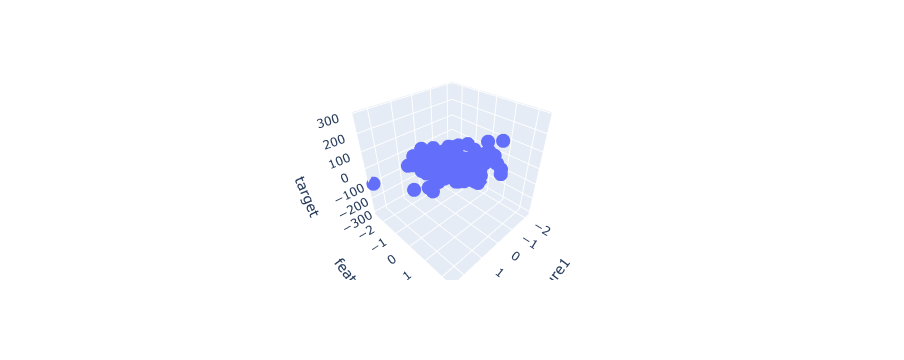

In [6]:
import plotly.io as pio
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.show()

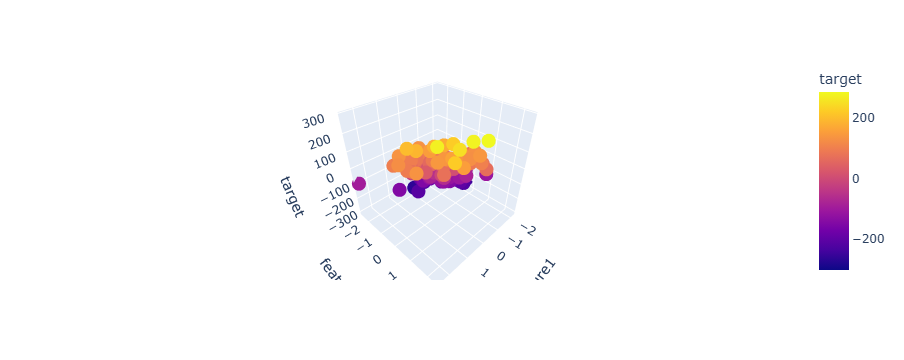

In [7]:
fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='target',
    color='target'
)
fig.show()

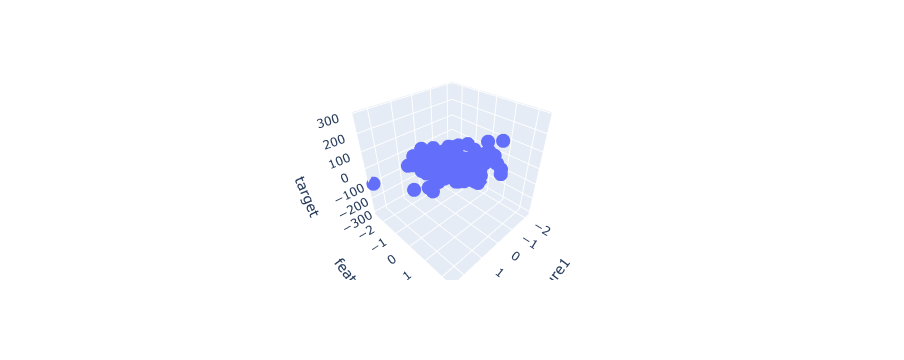

In [8]:
import plotly.express as px
import plotly.io as pio

fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.show()


In [9]:
# train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [10]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [11]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred = lr.predict(X_test)

In [13]:
y_pred

array([ 138.31691604,   36.60704092,  -30.87694714,   60.24956525,
         76.76094982,   -5.0059604 ,  -59.08464704,  -24.15418739,
        -49.56769768,  138.28510607,   -4.2202037 ,  168.12884895,
        306.99259408,  -83.54145007,   69.90902246,   19.80586842,
        -38.75505537, -120.87796573,  -53.2160447 ,  156.68783372])

In [14]:

print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))
     

MAE 41.395930541711884
MSE 2327.745995762313
R2 score 0.8297463925892183


In [15]:
X_test.shape

(20, 2)

In [16]:
print(lr.coef_[0])
print(lr.coef_[1])
print(lr.intercept_)

85.74463435026114
101.59639079217548
-4.551446714701436


In [17]:
w1=lr.coef_[0]
w2=lr.coef_[1]
b=lr.intercept_

In [18]:
x = np.linspace(df['feature1'].min(), df['feature1'].max(), 30)
y = np.linspace(df['feature2'].min(), df['feature2'].max(), 30)

xGrid, yGrid = np.meshgrid(x, y)


In [19]:
z_plane = w1 * xGrid + w2 * yGrid + b


In [20]:
x_vals = np.linspace(df['feature1'].min(), df['feature1'].max(), 100)
y_vals = -(w1 * x_vals + b) / w2


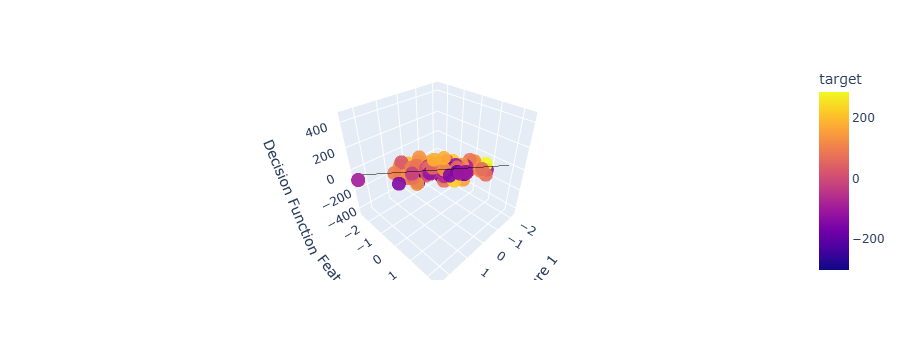

In [22]:
import plotly.graph_objects as go
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='target',      # original labels for reference
    color='target',
    opacity=0.9
)

# Add the decision boundary plane
fig.add_trace(
    go.Surface(
        x=xGrid,
        y=yGrid,
        z=z_plane,
        opacity=0.4,
        showscale=False,
        colorscale=[[0, 'lightgreen'], [1, 'lightgreen']]
    )
)

# Optional: highlight z=0 contour
fig.update_traces(
    selector=dict(type='surface'),
    contours=dict(
        z=dict(show=True, start=0, end=0, color="black", width=3)
    )
)

fig.update_layout(
    scene=dict(
        xaxis_title='Feature 1',
        yaxis_title='Feature 2',
        zaxis_title='Decision Function'
    )
)

fig.show()


In [23]:

x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

z = z_final


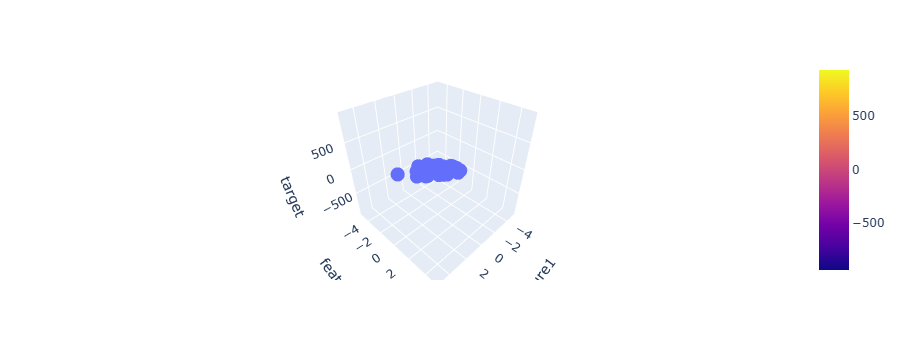

In [24]:

fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()
     